# <font color="purple"><h3 align="center">Exploratory Data Analysis (EDA)</h3></font>

# <font color='red'>IPL Auction 2023</font>

## <font color='red'>About the Data</font>

Welcome to the IPL 2023 Auction dataset, a comprehensive compilation of data capturing the high-stakes player auctions in the cricketing world. This dataset contains the details of the IPL 2023 auction and the player's status for the next IPL edition.

## Attributes:

1. names: Names of the players.
2. player style: This represents the playing style of the player (Bowler, Batter, AllRounder, WK-Batter).
3. nationality: This represents the nationality of the player.
4. base price (in lacs): This column represents the base price of the player. The values are in lacs.
5. final price (in lacs): This represents the final price of the player. The values are in lacs.

## Franchise:

This attribute contains the name of the franchise to which the player belongs
(CSK,MI,KKR,RR,LSG,DC,RCB,GT,SRH,PBKS).

## Status:

This represents the status of players ( RETAINED, SOLD, UNSOLD).

## <font color='red'>Step of EDA Process</font>

1. Understanding the data
2. Data loading & Initial Inspection
3. Data Cleaning
   - Handle missing values
   - Fix data types
   - Remove duplicates
4. Univariate Analysis
5. Target Summarize
6. Bivariate Analysis
7. Correlation Analysis
8. Insight Generation
9. Visualization Idea's


## <font color='red'>1. Understanding the data</font>

1. names: Names of the players.
2. player style: This represents the playing style of the player (Bowler, Batter, AllRounder, WK-Batter).
3. nationality: This represents the nationality of the player.
4. base price (in lacs): This column represents the base price of the player. The values are in lacs.
5. final price (in lacs): This represents the final price of the player. The values are in lacs.
6. franchise: This column represent the team of the player
7. status: This column represent whether the player is retained/sold/unsold

## <font color='red'>2.1 Data Loading</font>

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

ipl_auction_2023 = pd.read_csv("iplauction2023.csv")

## <font color='red'>Initial Inspection</font>

## Checks:

1. Number of records
2. Column names + data types
   
        → Helps you plan what analysis makes sense

## <font color='blue'>1st Five columns</font>

In [5]:
ipl_auction_2023.head()

,name,player style,nationality,base price (in lacs),final price (in lacs),franchise,status
0,Harshit Rana,Bowler,India,NaN,20.0,KKR,RETAINED
1,Ekant Sen,Batter,India,20.0,NaN,NaN,UNSOLD
2,Wayne Parnell,Allrounder,South Africa,75.0,NaN,NaN,UNSOLD
3,Shakib Al Hasan,Allrounder,Bangladesh,150.0,150.0,KKR,SOLD
4,Joe Root,Batter,England,100.0,100.0,RR,SOLD


## <font color='blue'>List of Columns</font>

In [9]:
list(ipl_auction_2023.columns)

['name',
 'player style',
 'nationality',
 'base price (in lacs)',
 'final price (in lacs)',
 'franchise',
 'status']

## <font color='blue'>Shape and Info</font>

In [12]:
ipl_auction_2023.shape

(309, 7)

In [13]:
ipl_auction_2023.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 309 entries, 0 to 308
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   name                   309 non-null    object 
 1   player style           309 non-null    object 
 2   nationality            309 non-null    object 
 3   base price (in lacs)   151 non-null    float64
 4   final price (in lacs)  238 non-null    float64
 5   franchise              238 non-null    object 
 6   status                 309 non-null    object 
dtypes: float64(2), object(5)
memory usage: 17.0+ KB


#### From the above analysis

- The data set contains 7 columns with 309 records

## <font color='red'>Data Cleaning</font>

#### Handling Missing Data

In [14]:
ipl_auction_2023.isnull().sum()

name                       0
player style               0
nationality                0
base price (in lacs)     158
final price (in lacs)     71
franchise                 71
status                     0
dtype: int64

In [18]:
# Checking why does the null value occurs in the base price

ipl_auction_2023[ipl_auction_2023["base price (in lacs)"].isnull()] 

,name,player style,nationality,base price (in lacs),final price (in lacs),franchise,status
0,Harshit Rana,Bowler,India,NaN,20.0,KKR,RETAINED
152,Rajat Patidar,Batter,India,NaN,20.0,RCB,RETAINED
153,Matheesha Pathirana,Bowler,Sri Lanka,NaN,20.0,CSK,RETAINED
154,Tristan Stubbs,WK-Batter,South Africa,NaN,20.0,MI,RETAINED
155,Ravi Bishnoi,Bowler,India,NaN,400.0,LSG,RETAINED
...,...,...,...,...,...,...,...
304,MS Dhoni,WK-Batter,India,NaN,1200.0,CSK,RETAINED
305,Moeen Ali,Allrounder,England,NaN,800.0,CSK,RETAINED
306,Ruturaj Gaikwad,Batter,India,NaN,600.0,CSK,RETAINED
307,Rishabh Pant,WK-Batter,India,NaN,1600.0,DC,RETAINED


In [22]:
# As all the players are RETAINED from the team we can able to make any changes within the base price column

ipl_auction_2023[ipl_auction_2023["base price (in lacs)"].isnull()]["status"].unique()

array(['RETAINED'], dtype=object)

In [45]:
## Checking why does the null value occurs in the final price price

ipl_auction_2023[ipl_auction_2023["final price (in lacs)"].isnull()] 

,name,player style,nationality,base price (in lacs),final price (in lacs),franchise,status


In [46]:
ipl_auction_2023[ipl_auction_2023["final price (in lacs)"].isnull()]["status"].unique()

# Filling the null values instead of removing them 

ipl_auction_2023.fillna({
    'final price (in lacs)' : 0,
    'franchise' : 'Player Unsold'
}, inplace = True)

In [43]:
# grouping up of the players based on the franchesis

ipl_auction_2023.groupby("franchise").size()

franchise
CSK              25
DC               24
GT               25
KKR              19
LSG              25
MI               23
PBKS             22
Player Unsold    71
RCB              25
RR               25
SRH              25
dtype: int64

## <font color='red'>Univariate Analysis</font>

### Identify the column type

- Numeric Columns
- Categorical Columns

In [48]:
ipl_auction_2023.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 309 entries, 0 to 308
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   name                   309 non-null    object 
 1   player style           309 non-null    object 
 2   nationality            309 non-null    object 
 3   base price (in lacs)   151 non-null    float64
 4   final price (in lacs)  309 non-null    float64
 5   franchise              309 non-null    object 
 6   status                 309 non-null    object 
dtypes: float64(2), object(5)
memory usage: 17.0+ KB


## Column Types:

-  [Nationality, franchise, stauts] - Categorical Column
-  [base price, final price] - Numeric Column 

## <font color='blue'>Numeric Columns</font>

#### Summary Statistics

In [49]:
ipl_auction_2023["base price (in lacs)"].describe()

count    151.000000
mean      59.205298
std       59.688337
min       20.000000
25%       20.000000
50%       20.000000
75%       75.000000
max      200.000000
Name: base price (in lacs), dtype: float64

In [50]:
ipl_auction_2023["final price (in lacs)"].describe()

count     309.000000
mean      283.495146
std       423.355778
min         0.000000
25%        20.000000
50%        50.000000
75%       400.000000
max      1850.000000
Name: final price (in lacs), dtype: float64

#### Histogram distribution

In [2]:
import numpy as np

ipl_auction_2023["base price (in lacs)"].replace(0, np.nan, inplace = True)
ipl_auction_2023["final price (in lacs)"].replace(0, np.nan, inplace = True)

ipl_auction_2023

C:\Users\ravim.SEDHU\AppData\Local\Temp\ipykernel_4768\2411241780.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  ipl_auction_2023["base price (in lacs)"].replace(0, np.nan, inplace = True)
C:\Users\ravim.SEDHU\AppData\Local\Temp\ipykernel_4768\2411241780.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting valu

,name,player style,nationality,base price (in lacs),final price (in lacs),franchise,status
0,Harshit Rana,Bowler,India,NaN,20.0,KKR,RETAINED
1,Ekant Sen,Batter,India,20.0,NaN,NaN,UNSOLD
2,Wayne Parnell,Allrounder,South Africa,75.0,NaN,NaN,UNSOLD
3,Shakib Al Hasan,Allrounder,Bangladesh,150.0,150.0,KKR,SOLD
4,Joe Root,Batter,England,100.0,100.0,RR,SOLD
...,...,...,...,...,...,...,...
304,MS Dhoni,WK-Batter,India,NaN,1200.0,CSK,RETAINED
305,Moeen Ali,Allrounder,England,NaN,800.0,CSK,RETAINED
306,Ruturaj Gaikwad,Batter,India,NaN,600.0,CSK,RETAINED
307,Rishabh Pant,WK-Batter,India,NaN,1600.0,DC,RETAINED


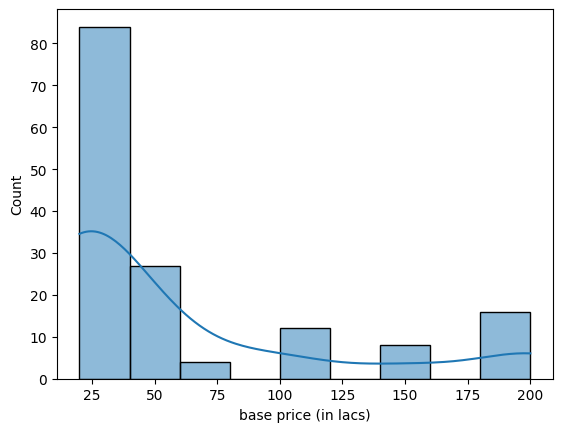

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(ipl_auction_2023["base price (in lacs)"].dropna(), kde=True)

plt.show()

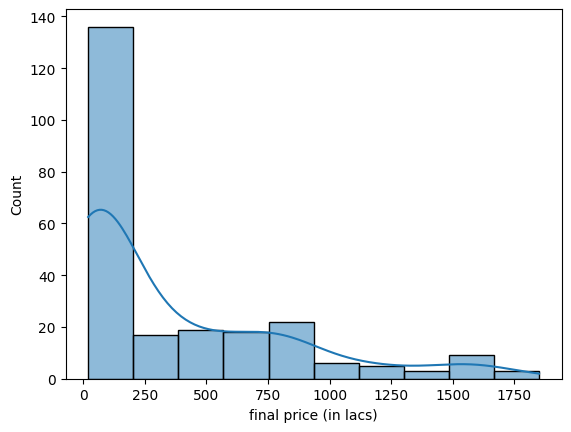

In [68]:
sns.histplot(ipl_auction_2023["final price (in lacs)"].dropna(), kde=True)

plt.show()

#### Boxplot (Outliers Check)

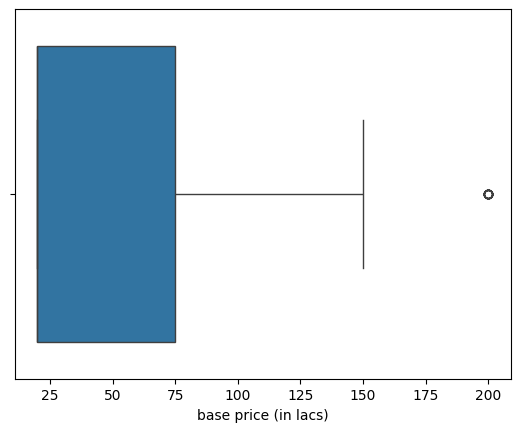

In [69]:
sns.boxplot(x = ipl_auction_2023["base price (in lacs)"])

plt.show()

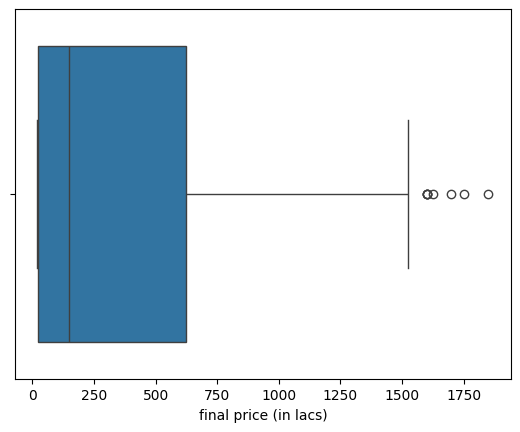

In [70]:
sns.boxplot(x = ipl_auction_2023["final price (in lacs)"])

plt.show()

#### Skwness

In [71]:
ipl_auction_2023['base price (in lacs)'].skew()


np.float64(1.4759428885724521)

In [73]:
ipl_auction_2023['final price (in lacs)'].skew()

np.float64(1.4035924943988667)

## <font color='red'>Report of Univariate Analysis</font>

## Base Price

- The base price of players ranges from 20 lacs to 200 lacs. The median base price is 20 lacs, indicating that at least 50% of the players have the minimum base price. However, the mean base price is around 59 lacs due to a few high-value players, which creates a right-skewed distribution. The histogram confirms that most players fall in the lower price range, and the boxplot reveals the presence of outliers at higher price levels.

## Final Price

- The final price of players ranges from base price (20 lacs) to 1850 lacs. The median final price is 50 lacs, indicating that at least 50% of the players were sold for 50 lacs or less. The mean final price is approximately 283 lacs, which is significantly higher than the median due to a few star players being sold at very high prices. This indicates a right-skewed distribution. The histogram shows that most players were sold in the lower price ranges, while the boxplot reveals the presence of extreme outliers at higher price levels, reaching up to 1850 lacs.

## <font color='red'>Bivaraite Analysis</font>

## 1. Base Price Vs Final Price Analysis

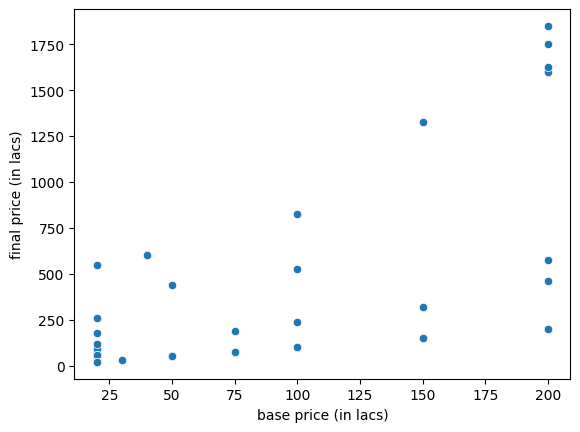

In [4]:
sns.scatterplot(
    x = 'base price (in lacs)',
    y = 'final price (in lacs)',
    data = ipl_auction_2023
)

plt.show()

## <font color='blue'>Insight Analysis</font>

- Players with higher base prices generally tend to have higher final prices, but there are several players with low base prices who were sold for very high amounts upto (600 lacs), indicating strong bidding competition.

## 2. Player Style Vs Final Price

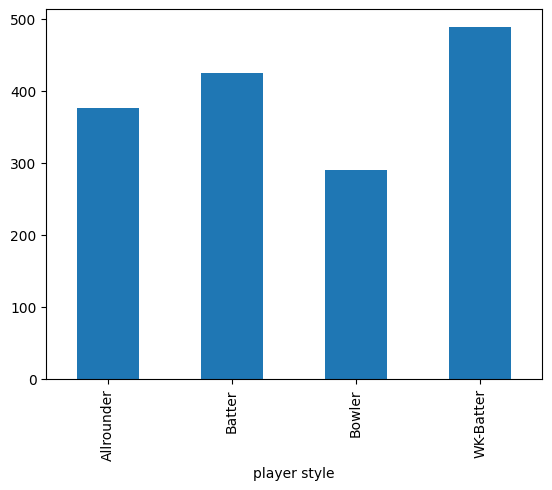

In [8]:
ipl_auction_2023.groupby('player style')['final price (in lacs)'].mean().plot(kind = 'bar')

plt.show()

## <font color='blue'>Insight Analysis</font>

- WK - Batter has the average final price compared to the other styles(Batter/Bowler/All-Rounder)

## 3. Franchise vs Total Spending

In [13]:
ipl_auction_2023.groupby('franchise')['final price (in lacs)'].sum()

franchise
CSK     9350.0
DC      8685.0
GT      9055.0
KKR     6410.0
LSG     9065.0
MI      9420.0
PBKS    8280.0
RCB     9325.0
RR      9165.0
SRH     8845.0
Name: final price (in lacs), dtype: float64

## <font color='blue'>Insight Analysis</font>

- Some franchises spent more than others, indicating aggressive bidding strategies.

## 4. Player Type Vs Status 

In [15]:
pd.crosstab(ipl_auction_2023['player style'],ipl_auction_2023['status'])

status,RETAINED,SOLD,UNSOLD
player style,,,
Allrounder,45,32,26
Batter,32,12,11
Bowler,62,25,24
WK-Batter,19,11,10


## <font color='blue'>Insight Analysis</font>

- Overall, the analysis shows that all-rounders and bowlers are the most valued player types, with high retained and sold counts, while batters are mostly retained rather than newly bought, and wicket-keeper batters are limited due to their specialized role.

## 5. Status Vs Final Price 

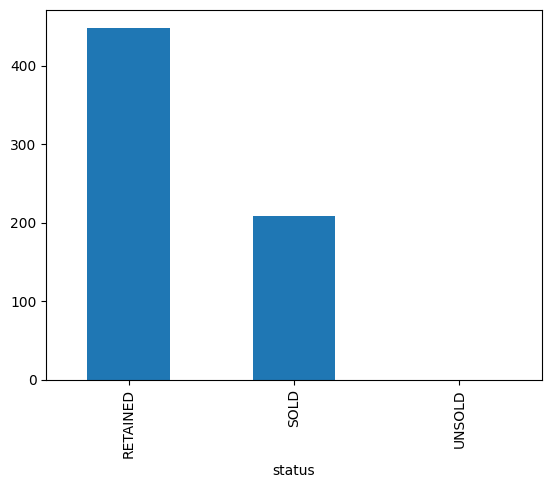

In [19]:
ipl_auction_2023.groupby('status')['final price (in lacs)'].mean().plot(kind = 'bar')

plt.show()

## <font color='blue'>Insight Analysis</font>

- Most players were retained by their franchises before the auction, fewer players were newly purchased during the auction, and only a small number of players remained unsold. This indicates that teams relied more on their existing squad rather than making many new purchases.

## <font color='red'>Multivariate Analysis</font>

## 1. Player Style + Franchise Vs Final Price 

In [3]:
pd.pivot_table(
    ipl_auction_2023,
    values = 'final price (in lacs)',
    index = 'franchise',
    columns = 'player style',
    aggfunc = 'mean'
)

player style,Allrounder,Batter,Bowler,WK-Batter
franchise,,,,
CSK,486.500,158.000000,227.500000,937.500000
DC,331.000,328.125000,280.500000,1600.000000
GT,552.000,316.000000,376.818182,142.500000
KKR,466.250,443.333333,201.666667,70.000000
LSG,223.750,20.000000,265.000000,1325.000000
MI,338.125,578.000000,322.857143,521.666667
PBKS,398.125,453.750000,360.714286,251.666667
RCB,383.750,562.500000,303.500000,323.333333
RR,299.000,531.250000,277.727273,498.000000


## <font color='blue'>Insight Analysis</font>

- Different franchises show different spending priorities, with some focusing on all-rounders, others on strong batters or bowlers, while a few teams made very high investments in wicket-keeper batters, reflecting varied auction strategies.

## 2. Player Style + Status Vs Final Price 

In [6]:
pd.pivot_table(
    ipl_auction_2023,
    values = 'final price (in lacs)',
    index = 'player style',
    columns = 'status',
    aggfunc = 'mean'
)

status,RETAINED,SOLD
player style,,
Allrounder,475.555556,236.718750
Batter,474.218750,294.166667
Bowler,358.145161,122.200000
WK-Batter,637.894737,230.909091


## <font color='blue'>Insight Analysis</font> 

- Across all player styles, retained players have significantly higher average prices than sold players, showing that franchises prefer to keep their most valuable players rather than risking them in the auction.

## 3. Franchise + Status count

In [7]:
pd.crosstab(
    ipl_auction_2023['franchise'],
    ipl_auction_2023['status']
)

status,RETAINED,SOLD
franchise,,
CSK,18,7
DC,19,5
GT,18,7
KKR,11,8
LSG,15,10
MI,15,8
PBKS,16,6
RCB,18,7
RR,16,9


## <font color='blue'>Insight Analysis</font>

- Most franchises preferred retaining their core players rather than making many new purchases, while teams like SRH, LSG, and RR were more active in the auction by buying more players.

## 4. Heat Map

In [10]:
pivot = pd.pivot_table(
    ipl_auction_2023,
    values = 'final price (in lacs)',
    index = 'franchise',
    columns = 'player style',
    aggfunc = 'mean'
).round(0)

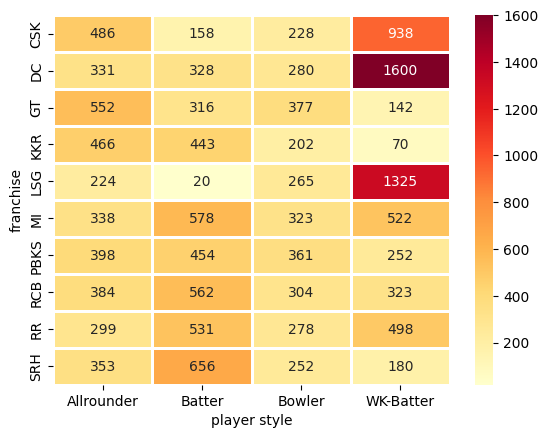

In [11]:
sns.heatmap(pivot, 
            annot = True,
           linewidths = 1,
           fmt = '.0f',
           cmap = 'YlOrRd')
plt.show()

## <font color='blue'>Insight Analysis</font>

- Most teams prioritized Batters and Allrounders, but DC and LSG uniquely focused on expensive WK-Batters, showing a different auction strategy compared to other franchises.

## <font color='red'>Advanced Analysis / Conclusion Level</font>

## 1. Correlation Analysis

Check relation between numeric columns.

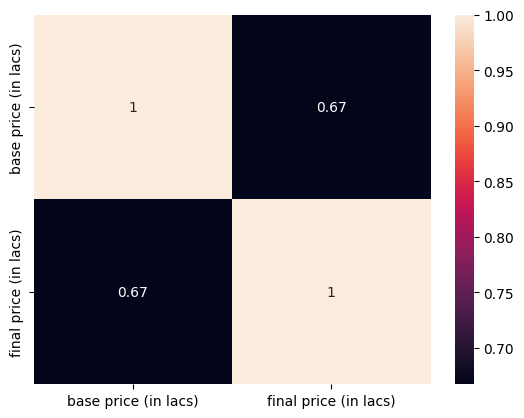

In [13]:
ipl_auction_2023.corr(numeric_only = True)
sns.heatmap(ipl_auction_2023.corr(numeric_only = True), annot = True)

plt.show()

## 2. Outlier Detection

Check which players got very abnormal high price

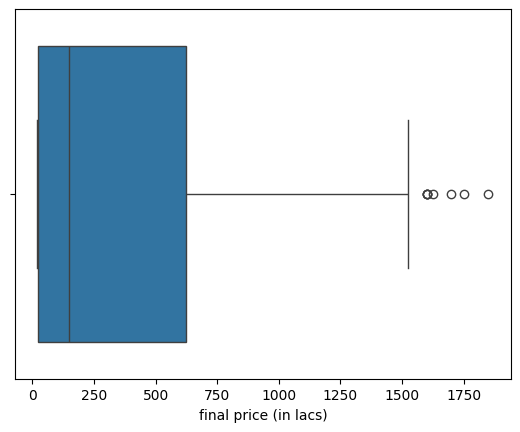

In [14]:
sns.boxplot(x = ipl_auction_2023['final price (in lacs)'])

plt.show()

## 3. Top 10 Expensive Players

In [16]:
ipl_auction_2023.sort_values('final price (in lacs)', ascending = False).head(10)

,name,player style,nationality,base price (in lacs),final price (in lacs),franchise,status
150,Sam Curran,Allrounder,England,200.0,1850.0,PBKS,SOLD
148,Cameron Green,Allrounder,Australia,200.0,1750.0,MI,SOLD
292,KL Rahul,WK-Batter,India,NaN,1700.0,LSG,RETAINED
147,Ben Stokes,Allrounder,England,200.0,1625.0,CSK,SOLD
307,Rishabh Pant,WK-Batter,India,NaN,1600.0,DC,RETAINED
136,Nicholas Pooran,WK-Batter,West Indies,200.0,1600.0,LSG,SOLD
290,Rohit Sharma,Batter,India,NaN,1600.0,MI,RETAINED
296,Ravindra Jadeja,Allrounder,India,NaN,1600.0,CSK,RETAINED
230,Ishan Kishan,WK-Batter,India,NaN,1525.0,MI,RETAINED
300,Rashid Khan,Bowler,Afghanistan,NaN,1500.0,GT,RETAINED


## 4. Franchise Spending Analysis

In [17]:
ipl_auction_2023.groupby('franchise')['final price (in lacs)'].sum().sort_values(ascending = False)

franchise
MI      9420.0
CSK     9350.0
RCB     9325.0
RR      9165.0
LSG     9065.0
GT      9055.0
SRH     8845.0
DC      8685.0
PBKS    8280.0
KKR     6410.0
Name: final price (in lacs), dtype: float64

## 5. Player Style vs Sold Rate

In [19]:
pd.crosstab(
    ipl_auction_2023['player style'],
    ipl_auction_2023['status'],
    normalize = 'index'
) * 100

status,RETAINED,SOLD,UNSOLD
player style,,,
Allrounder,43.689320,31.067961,25.242718
Batter,58.181818,21.818182,20.000000
Bowler,55.855856,22.522523,21.621622
WK-Batter,47.500000,27.500000,25.000000
